# Posterior for S. aureus local recombination rate using SBI

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import Phylo
import torch
from torch.distributions import Uniform
from sbi.utils.user_input_checks import MultipleIndependent
from sbi.inference import NPE_C
from sbi.analysis import plot_summary
import sys
sys.path.append('../pysimARG')
from discrete_uniform import DiscreteUniform

torch_device = "cpu"

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load simulation data

Load staph gene data and clonal tree.

In [2]:
# Load phylo tree and convert to ClonalTree format
phylo_tree = Phylo.read("../data/staph/saureus_clonal.nwk", "newick")
Phylo.draw_ascii(phylo_tree)

                                                                   , C1139
                                                                  ,|
                                                                  |, C9658
                                                                  ||
                                                                  |, C1282
                                                                  ||
                      ____________________________________________|, C1280
                     |                                            ||
                     |                                            || C1080
                     |                                            |
                     |                                            |_ C1079
                     |                                            |
                     |                                            , C1147
                     |                                          

In [3]:
x_obs_df = pd.read_csv("../data/staph/core_gene_summary_stats.csv", index_col=0)
x_obs_np = x_obs_df.to_numpy()
x_obs_torch = torch.tensor(x_obs_np, device=torch_device)
x_obs_torch = x_obs_torch.to(torch.float32)
x_obs_torch.shape, x_obs_torch.dtype

(torch.Size([1983, 46]), torch.float32)

### Delete observations with no signal

In [4]:
no_signal_id = np.where(x_obs_np[:, 33] == 0)[0]
no_signal_id.shape, no_signal_id[:10]

((18,), array([ 137,  140,  236,  657,  659,  767,  773, 1036, 1485, 1497]))

In [5]:
x_obs_np = np.delete(x_obs_np, no_signal_id, axis=0)
x_obs_torch = torch.tensor(x_obs_np, device=torch_device)
x_obs_torch = x_obs_torch.to(torch.float32)
x_obs_np.shape, x_obs_torch.shape, x_obs_torch.dtype

((1965, 46), torch.Size([1965, 46]), torch.float32)

## Load simulation data

In [6]:
theta1 = np.loadtxt('../data/staph/ClonalOrigin_sim/theta1.csv', delimiter=",")
x1 = np.loadtxt('../data/staph/ClonalOrigin_sim/x1.csv', delimiter=",")

theta2 = np.loadtxt('../data/staph/ClonalOrigin_sim/theta2.csv', delimiter=",")
x2 = np.loadtxt('../data/staph/ClonalOrigin_sim/x2.csv', delimiter=",")

theta3 = np.loadtxt('../data/staph/ClonalOrigin_sim/theta3.csv', delimiter=",")
x3 = np.loadtxt('../data/staph/ClonalOrigin_sim/x3.csv', delimiter=",")

x = np.vstack([x1, x2, x3])
theta = np.vstack([theta1, theta2, theta3])

print(theta.shape, x.shape)

(50000, 2) (50000, 46)


In [7]:
theta = torch.tensor(theta, device=torch_device)
theta = theta.to(torch.float32)
theta_numpy = theta.cpu().numpy()

x = torch.tensor(x, device=torch_device)
x = x.to(torch.float32)
x_numpy = x.cpu().numpy()

### Find out-of-range observations

In [8]:
ignore_indices = []
no_segregation = []
out_stats = dict()
for i in range(x_obs_torch.shape[0]):
    ignore_i = False
    out_index = []
    for j in range(46):
        max_j = torch.max(x[:, j])
        min_j = torch.min(x[:, j])
        obs_j = x_obs_torch[i, j]
        if obs_j < min_j or obs_j > max_j:
            ignore_i = True
            out_index.append(j)
        if j == 33 and obs_j == 0:
            no_segregation.append(i)
    if ignore_i or torch.isnan(x_obs_torch[i, :]).any():
        print(f"Observation {i} is outside the range of simulated data.")
        ignore_indices.append(i)
        out_stats[i] = out_index

Observation 5 is outside the range of simulated data.
Observation 6 is outside the range of simulated data.
Observation 7 is outside the range of simulated data.
Observation 8 is outside the range of simulated data.
Observation 14 is outside the range of simulated data.
Observation 16 is outside the range of simulated data.
Observation 20 is outside the range of simulated data.
Observation 22 is outside the range of simulated data.
Observation 27 is outside the range of simulated data.
Observation 29 is outside the range of simulated data.
Observation 30 is outside the range of simulated data.
Observation 31 is outside the range of simulated data.
Observation 35 is outside the range of simulated data.
Observation 39 is outside the range of simulated data.
Observation 47 is outside the range of simulated data.
Observation 50 is outside the range of simulated data.
Observation 60 is outside the range of simulated data.
Observation 64 is outside the range of simulated data.
Observation 82

In [9]:
len(ignore_indices), len(no_segregation), len(out_stats)

(297, 0, 297)

In [10]:
out_index_all = []
for i in range(len(ignore_indices)):
    idx = ignore_indices[i]
    out_index_all += out_stats[idx]

In [11]:
from collections import Counter

integer_counts = Counter(out_index_all)

In [12]:
for i in range(32):
    print(f"Index {i}: {integer_counts[i]}")

Index 0: 7
Index 1: 5
Index 2: 1
Index 3: 1
Index 4: 8
Index 5: 7
Index 6: 0
Index 7: 0
Index 8: 0
Index 9: 5
Index 10: 0
Index 11: 0
Index 12: 0
Index 13: 19
Index 14: 0
Index 15: 0
Index 16: 149
Index 17: 134
Index 18: 2
Index 19: 4
Index 20: 263
Index 21: 177
Index 22: 2
Index 23: 1
Index 24: 0
Index 25: 0
Index 26: 0
Index 27: 0
Index 28: 0
Index 29: 0
Index 30: 0
Index 31: 0


In [13]:
for i in range(32, 46):
    print(f"Index {i}: {integer_counts[i]}")

Index 32: 0
Index 33: 1
Index 34: 1
Index 35: 4
Index 36: 24
Index 37: 0
Index 38: 0
Index 39: 0
Index 40: 0
Index 41: 0
Index 42: 1
Index 43: 0
Index 44: 1
Index 45: 0


Keep only proportion of LD $r^2$, proportion of G4, homoplasy index, proportion of segregating sites, Hudson's Rm estimator.

In [14]:
keep_columns = [12, 13, 14, 15, 32, 33, 40, 45]

In [15]:
len(keep_columns)

8

In [16]:
x_obs_np = x_obs_np[:, keep_columns]
x_obs_torch = torch.tensor(x_obs_np, device=torch_device)
x_obs_torch = x_obs_torch.to(torch.float32)
x_obs_np.shape, x_obs_torch.shape, x_obs_torch.dtype

((1965, 8), torch.Size([1965, 8]), torch.float32)

In [17]:
x = x[:, keep_columns]
x_numpy = x.cpu().numpy()
x.shape, x_numpy.shape

(torch.Size([50000, 8]), (50000, 8))

## NPE

### Create prior to pass range knowledge to NPE

In [18]:
prior_rho = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.1]))
prior_L = DiscreteUniform(low=torch.tensor([20.0]), high=torch.tensor([10000.0]))

prior = MultipleIndependent(
    dists=[prior_rho, prior_L],
    validate_args=False,
    device=torch_device
)

In [19]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [20]:
density_estimator = inference.append_simulations(theta, x).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior = inference.build_posterior(density_estimator)

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\sbi\inference\trainers\npe\npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [0, 1, 4, 5] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 135 epochs.

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\sbi-logs\NPE_C\2026-06-26T14_42_26.029613' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


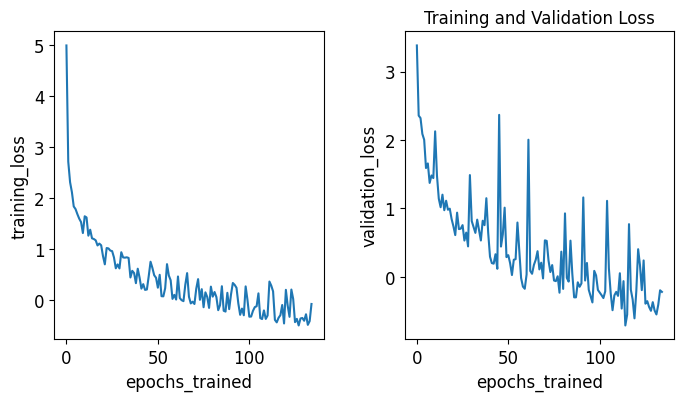

In [21]:
fig, axes = plot_summary(
    inference, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

### Plug in observation data to get posterior

In [22]:
theta_post = np.full((x_obs_torch.shape[0], num_posterior_samples, 2), np.nan)
theta_post.shape

(1965, 1000, 2)

In [23]:
for i in range(x_obs_torch.shape[0]):
    # if i in ignore_indices:
    #     continue

    theta_post_torch = posterior.sample((num_posterior_samples,), x=x_obs_torch[i, :],
                                        show_progress_bars=False, reject_outside_prior=False)
    theta_post[i, :, :] = theta_post_torch.cpu().detach().numpy()

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\nflows\transforms\lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\BatchLinearAlgebra.cpp:2196.)
  outputs, _ = torch.triangular_solve(
C:\Users\u2008181\AppData\Local\Temp\ipykernel_21320\3238161204.py:5: UserWarning: 50.6% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  theta_post_torch = posterior.sample((num_posterior_samples,), x=x_obs_torch[i, :],
C:\Users\u2008181\AppData\Local\Temp\ipykernel_21320\3238161204.py:5: UserWarning: 69.3%

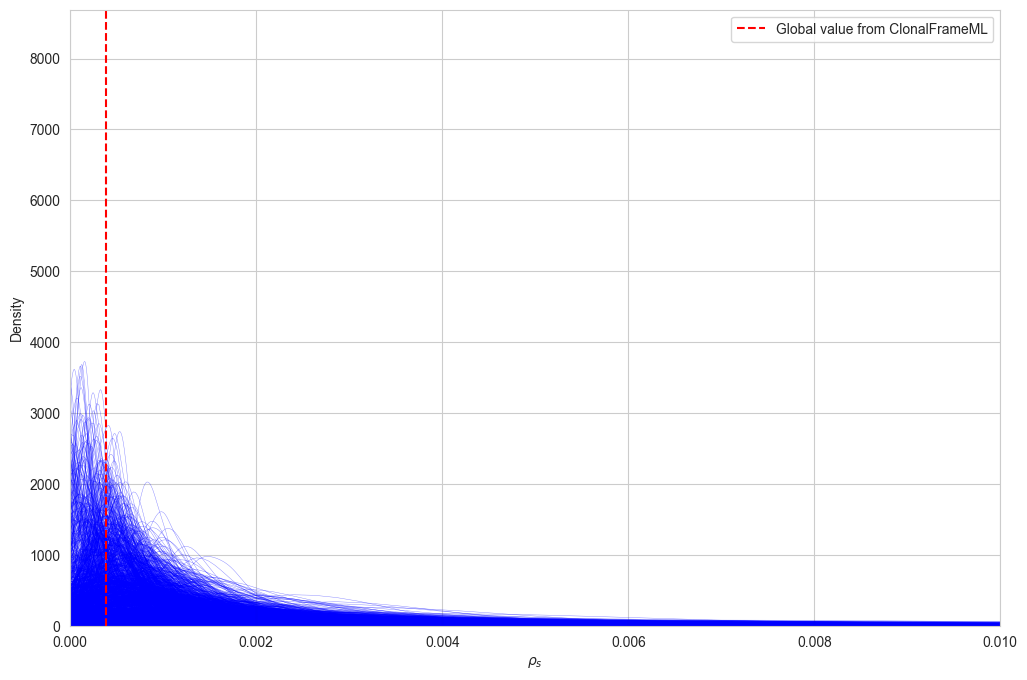

In [24]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
for i in range(0, x_obs_torch.shape[0]):
    if i in ignore_indices:
        continue
    sns.kdeplot(theta_post[i, :, 0], color='blue', linewidth=0.3, alpha=0.5)
plt.axvline(x=0.0003887292720131564, color='red', linestyle='dashed', label='Global value from ClonalFrameML')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.01)
plt.legend()
plt.show()

### Plot bar plots by position

In [25]:
gene_info = pd.read_csv("../data/staph/core_gene_info.csv", index_col=0)
gene_info_np = gene_info.to_numpy()
gene_info.head()

,Gene_Length,Start_pos,End_pos,Alignment
Gene_ID,,,,
dnaA,1362,517,1878,True
dnaN,1134,2156,3289,True
SAR0003,246,3670,3915,True
recF,1113,3912,5024,True
gyrB,1932,5037,6968,True


In [26]:
plot_xlim = [0.0, 2902619.0]
samples_x = np.delete(gene_info_np[:, 1], no_signal_id)
samples_x.shape

(1965,)

In [27]:
posterior_median = np.median(theta_post[:, :, 0], axis=1)
posterior_median.shape

(1965,)

In [28]:
ci_lower_bounds = np.percentile(theta_post[:, :, 0], 2.5, axis=1)
ci_upper_bounds = np.percentile(theta_post[:, :, 0], 97.5, axis=1)
ci_lower_bounds.shape, ci_upper_bounds.shape

((1965,), (1965,))

In [29]:
lower_errors = posterior_median - ci_lower_bounds
upper_errors = ci_upper_bounds - posterior_median
yerr = [lower_errors, upper_errors]

In [30]:
median_rho = np.median(posterior_median)
median_rho

np.float64(0.0006837399851065129)

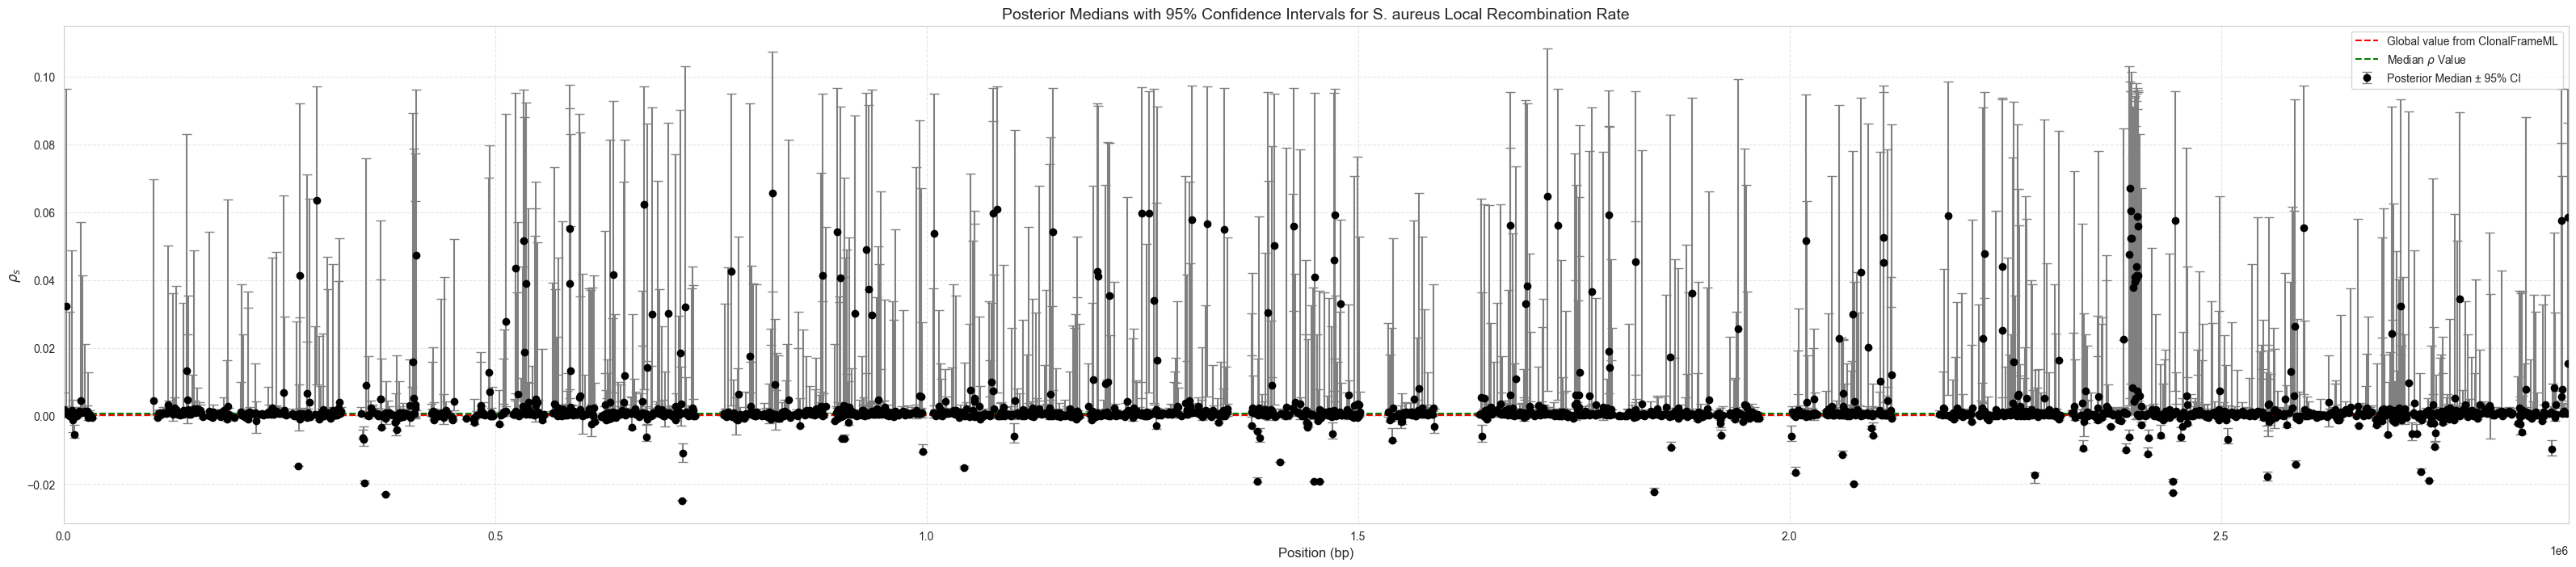

In [31]:
plt.figure(figsize=(40, 8))
plt.errorbar(samples_x, posterior_median, yerr=yerr, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, 
             label='Posterior Median ± 95% CI')

plt.title("Posterior Medians with 95% Confidence Intervals for S. aureus Local Recombination Rate", fontsize=14)
plt.xlabel("Position (bp)", fontsize=12)
plt.ylabel(r'$\rho_s$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(y=0.0003887292720131564, color='red', linestyle='dashed', label='Global value from ClonalFrameML')
plt.axhline(y=median_rho, color='green', linestyle='dashed', label=r'Median $\rho$ Value')
plt.xlim(plot_xlim)
plt.legend()
plt.show()

In [32]:
samples_l = np.delete(gene_info_np[:, 0], no_signal_id)
samples_l.shape

(1965,)

In [33]:
posterior_l_median = np.median(theta_post[:, :, 1], axis=1)
posterior_l_median.shape

(1965,)

In [34]:
ci_lower_bounds_l = np.percentile(theta_post[:, :, 1], 2.5, axis=1)
ci_upper_bounds_l = np.percentile(theta_post[:, :, 1], 97.5, axis=1)
ci_lower_bounds_l.shape, ci_upper_bounds_l.shape

((1965,), (1965,))

In [35]:
lower_l_errors = posterior_l_median - ci_lower_bounds_l
upper_l_errors = ci_upper_bounds_l - posterior_l_median
yerr_l = [lower_l_errors, upper_l_errors]

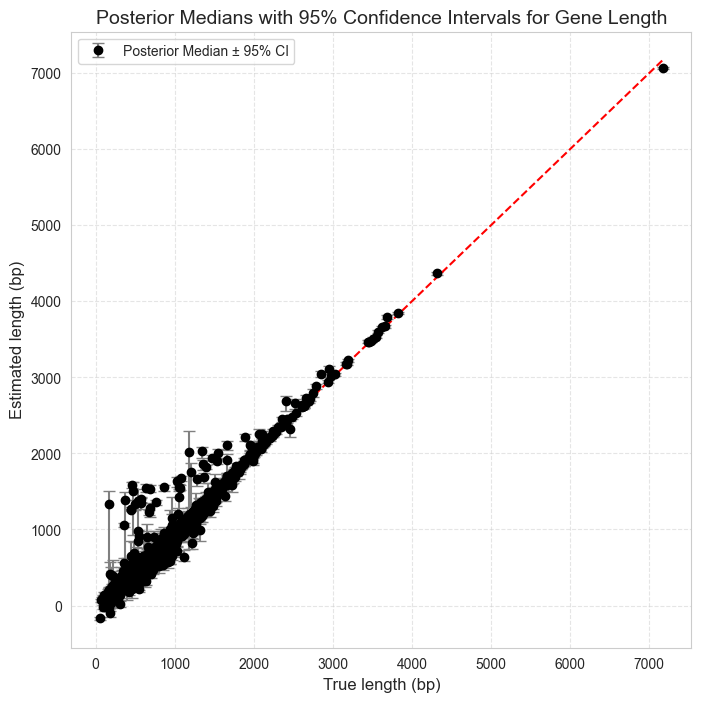

In [36]:
plt.figure(figsize=(8, 8))
plt.errorbar(samples_l, posterior_l_median, yerr=yerr_l, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, 
             label='Posterior Median ± 95% CI')

exact_x = np.linspace(np.min(samples_l), np.max(samples_l), 400)
exact_y = exact_x

plt.title("Posterior Medians with 95% Confidence Intervals for Gene Length", fontsize=14)
plt.xlabel("True length (bp)", fontsize=12)
plt.ylabel("Estimated length (bp)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.plot(exact_x, exact_y, color='red', linestyle='dashed')
plt.legend(loc='upper left')
plt.show()

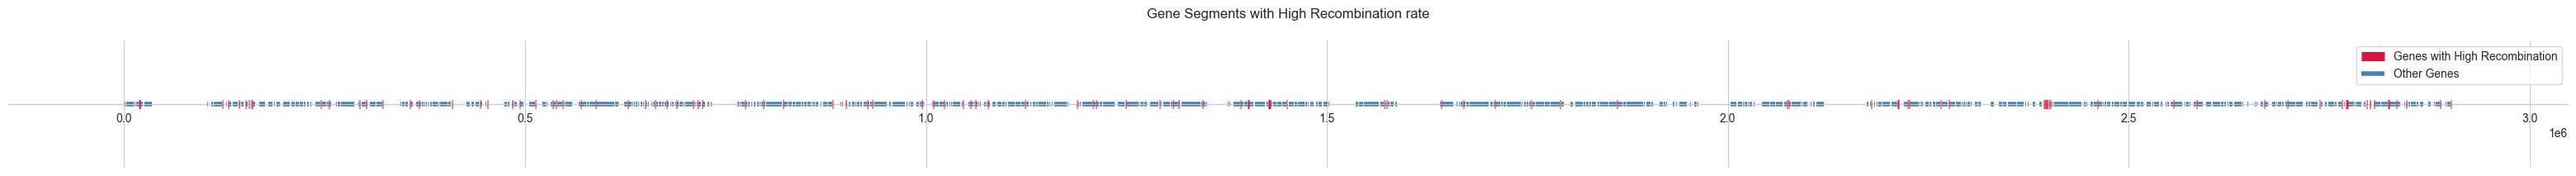

In [37]:
y_level = 0
gene_starts = np.delete(gene_info_np[:, 1], no_signal_id)
gene_ends   = np.delete(gene_info_np[:, 2], no_signal_id)

# high_recomb_index = np.where(ci_lower_bounds >= 0.0003887292720131564)[0]
high_recomb_index = np.where(ci_lower_bounds >= median_rho)[0]
highlight_starts = gene_starts[high_recomb_index]
highlight_ends   = gene_ends[high_recomb_index]

# other_genes_index = np.where(ci_lower_bounds < 0.0003887292720131564)[0]
other_genes_index = np.where(ci_lower_bounds < median_rho)[0]
other_starts = gene_starts[other_genes_index]
other_ends   = gene_ends[other_genes_index]

fig, ax = plt.subplots(figsize=(40, 2))

ax.axhline(y=y_level, color='lightgray', linewidth=1, zorder=1)
ax.hlines(y=[y_level] * len(highlight_starts), xmin=highlight_starts, xmax=highlight_ends, 
          color='crimson', linewidth=8, label='Genes with High Recombination', zorder=3)
ax.hlines(y=[y_level] * len(other_starts), xmin=other_starts, xmax=other_ends, 
          color='steelblue', linewidth=4, label='Other Genes', zorder=2)

ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_position('center')

ax.set_ylim(-1, 1)
ax.set_title("Gene Segments with High Recombination rate", pad=20)
ax.legend(loc='upper right')
plt.show()

### NPE in log-scale

In [38]:
theta_log = theta.clone()
theta_log[:, 0] = torch.log(theta_log[:, 0])
theta_log_numpy = theta_log.cpu().numpy()
theta_log_numpy.shape, theta_numpy.shape

((50000, 2), (50000, 2))

In [39]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference_log = NPE_C(density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [40]:
density_estimator_log = inference_log.append_simulations(theta_log, x).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior_log = inference_log.build_posterior(density_estimator_log)

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\sbi\inference\trainers\npe\npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [0, 1, 4, 5] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 139 epochs.

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\sbi\inference\potentials\posterior_based_potential.py:58: UserWarning: The passed prior has no support property, transform will be constructed from mean and std. If the passed prior is supposed to be bounded consider implementing the prior.support property.
  theta_transform = mcmc_transform(


For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\sbi-logs\NPE_C\2026-06-26T15_03_45.188175' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


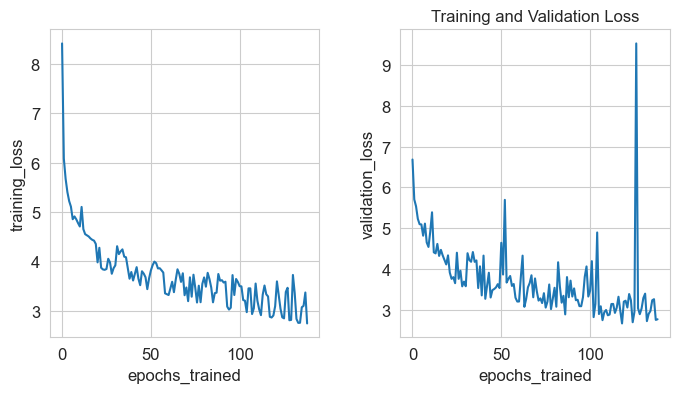

In [41]:
fig, axes = plot_summary(
    inference_log, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

### Plug in observation data to get posterior

In [42]:
theta_post_log = np.full((x_obs_torch.shape[0], num_posterior_samples, 2), np.nan)
theta_post_log.shape

(1965, 1000, 2)

In [43]:
for i in range(x_obs_torch.shape[0]):
    # if i in ignore_indices:
    #     continue

    theta_post_torch = posterior_log.sample((num_posterior_samples,), x=x_obs_torch[i, :],
                                            show_progress_bars=False, reject_outside_prior=False)
    theta_post_log[i, :, :] = theta_post_torch.cpu().detach().numpy()

In [44]:
theta_post_rescaled = theta_post_log.copy()
theta_post_rescaled[:, :, 0] = np.exp(theta_post_rescaled[:, :, 0])
theta_post_rescaled.shape, theta_post_log.shape

((1965, 1000, 2), (1965, 1000, 2))

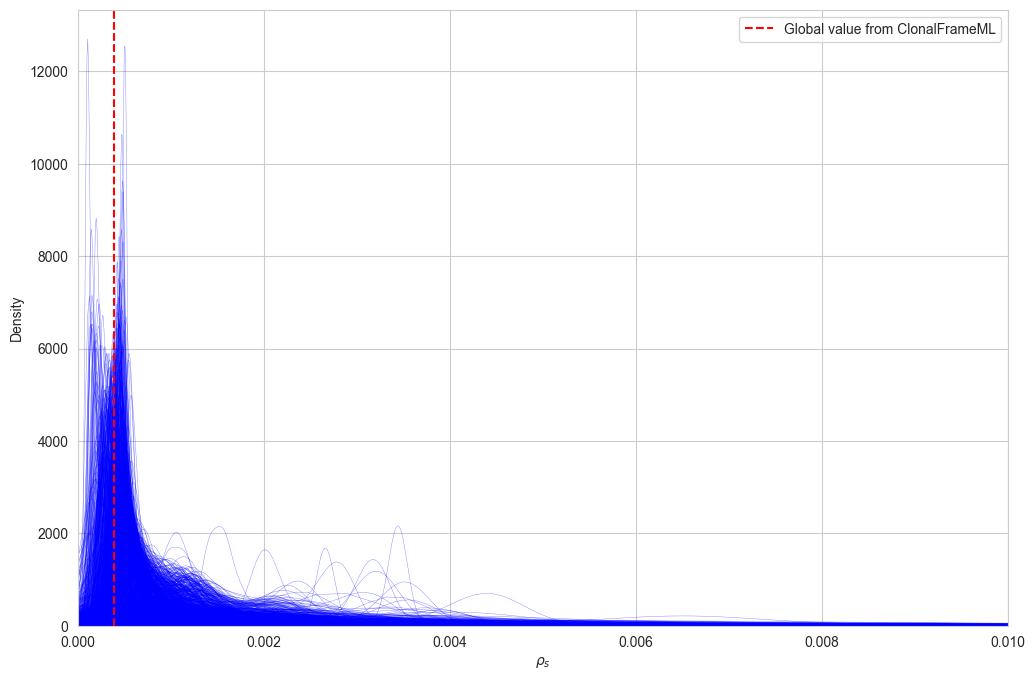

In [45]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
for i in range(0, x_obs_torch.shape[0]):
    if i in ignore_indices:
        continue
    sns.kdeplot(theta_post_rescaled[i, :, 0], color='blue', linewidth=0.3, alpha=0.5)
plt.axvline(x=0.0003887292720131564, color='red', linestyle='dashed', label='Global value from ClonalFrameML')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.01)
plt.legend()
plt.show()

### Plot bar plots by position

In [46]:
posterior_median_rescaled = np.median(theta_post_rescaled[:, :, 0], axis=1)
posterior_median_rescaled.shape

(1965,)

In [47]:
ci_lower_bounds_rescaled = np.percentile(theta_post_rescaled[:, :, 0], 2.5, axis=1)
ci_upper_bounds_rescaled = np.percentile(theta_post_rescaled[:, :, 0], 97.5, axis=1)
ci_lower_bounds_rescaled.shape, ci_upper_bounds_rescaled.shape

((1965,), (1965,))

In [48]:
lower_errors_rescaled = posterior_median_rescaled - ci_lower_bounds_rescaled
upper_errors_rescaled = ci_upper_bounds_rescaled - posterior_median_rescaled
yerr_rescaled = [lower_errors_rescaled, upper_errors_rescaled]

In [49]:
median_rho = np.median(posterior_median_rescaled)
median_rho

np.float64(0.0006421247021343381)

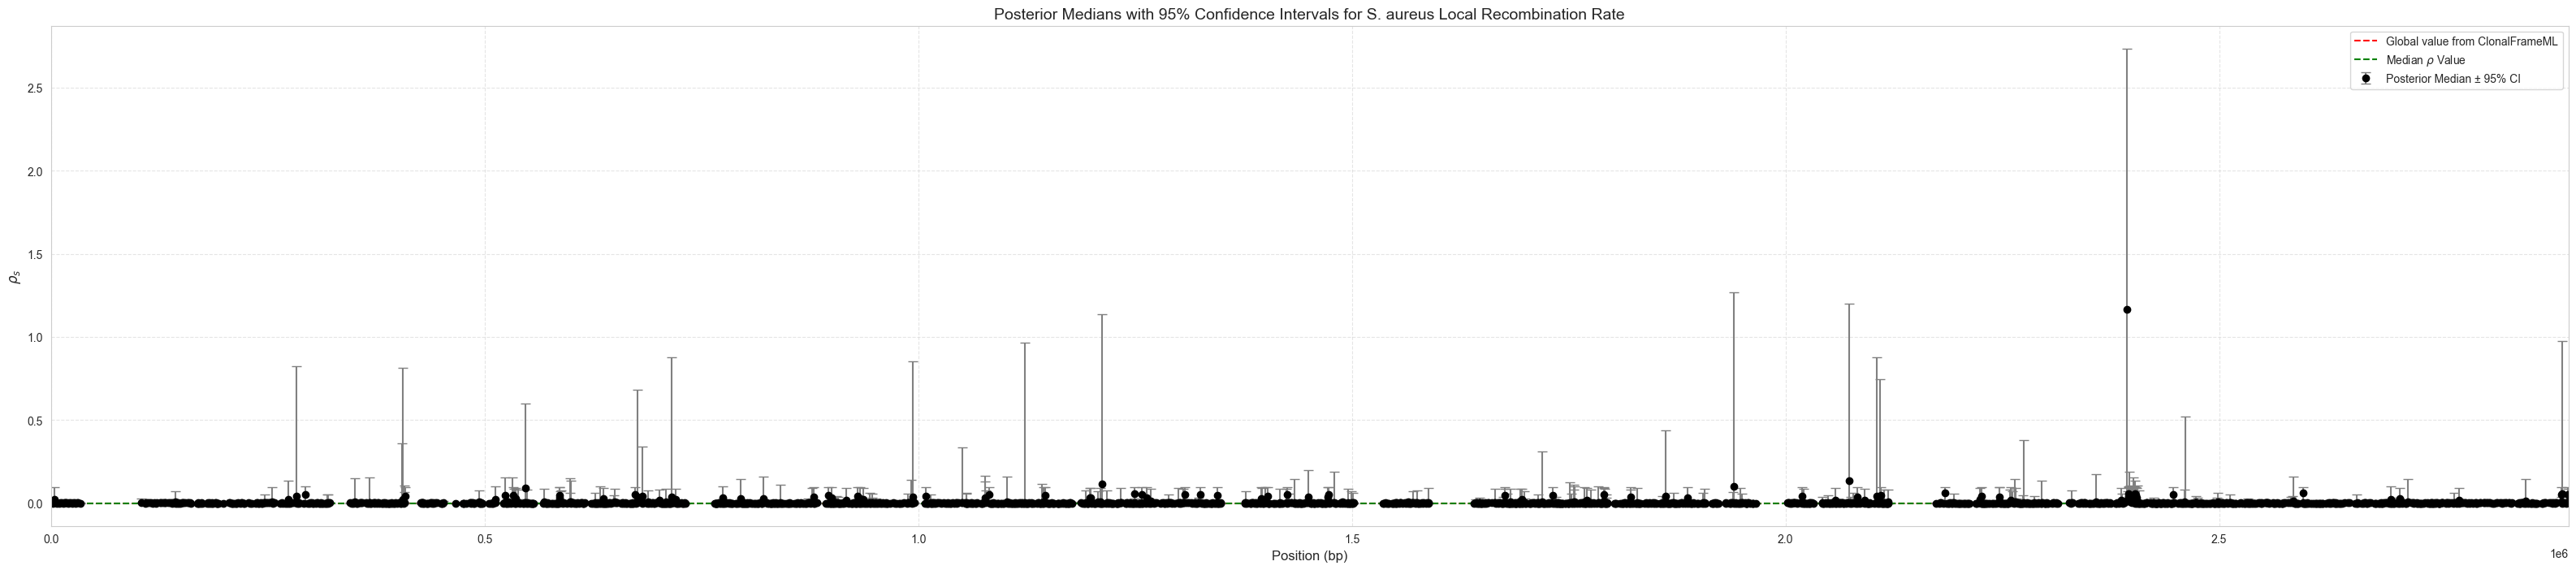

In [50]:
plt.figure(figsize=(40, 8))
plt.errorbar(samples_x, posterior_median_rescaled, yerr=yerr_rescaled, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, 
             label='Posterior Median ± 95% CI')

plt.title("Posterior Medians with 95% Confidence Intervals for S. aureus Local Recombination Rate", fontsize=14)
plt.xlabel("Position (bp)", fontsize=12)
plt.ylabel(r'$\rho_s$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(y=0.0003887292720131564, color='red', linestyle='dashed', label='Global value from ClonalFrameML')
plt.axhline(y=median_rho, color='green', linestyle='dashed', label=r'Median $\rho$ Value')
plt.xlim(plot_xlim)
plt.legend()
plt.show()

In [51]:
posterior_l_median_rescaled = np.median(theta_post_rescaled[:, :, 1], axis=1)
posterior_l_median_rescaled.shape

(1965,)

In [52]:
ci_lower_bounds_l_rescaled = np.percentile(theta_post_rescaled[:, :, 1], 2.5, axis=1)
ci_upper_bounds_l_rescaled = np.percentile(theta_post_rescaled[:, :, 1], 97.5, axis=1)
ci_lower_bounds_l_rescaled.shape, ci_upper_bounds_l_rescaled.shape

((1965,), (1965,))

In [53]:
lower_l_errors_rescaled = posterior_l_median_rescaled - ci_lower_bounds_l_rescaled
upper_l_errors_rescaled = ci_upper_bounds_l_rescaled - posterior_l_median_rescaled
yerr_l_rescaled = [lower_l_errors_rescaled, upper_l_errors_rescaled]

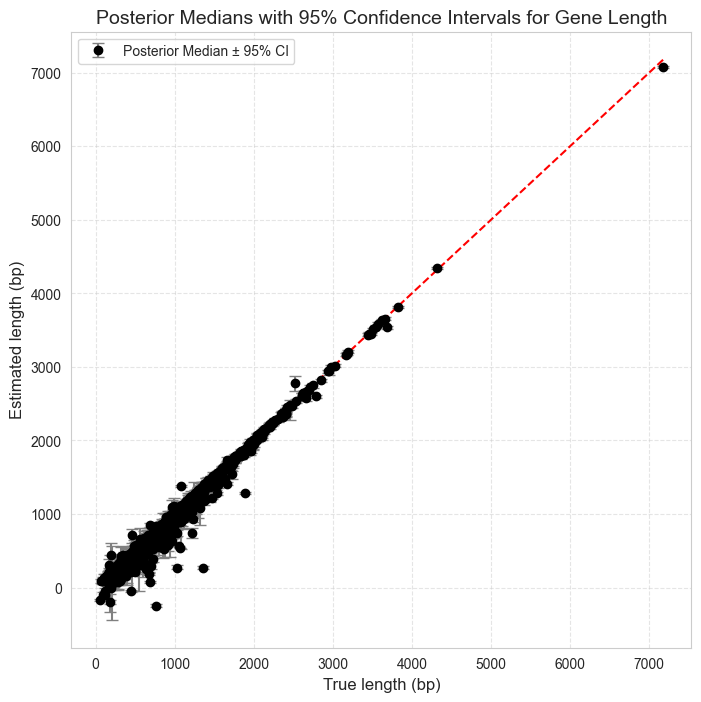

In [54]:
plt.figure(figsize=(8, 8))
plt.errorbar(samples_l, posterior_l_median_rescaled, yerr=yerr_l_rescaled, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, 
             label='Posterior Median ± 95% CI')

exact_x = np.linspace(np.min(samples_l), np.max(samples_l), 400)
exact_y = exact_x

plt.title("Posterior Medians with 95% Confidence Intervals for Gene Length", fontsize=14)
plt.xlabel("True length (bp)", fontsize=12)
plt.ylabel("Estimated length (bp)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.plot(exact_x, exact_y, color='red', linestyle='dashed')
plt.legend(loc='upper left')
plt.show()

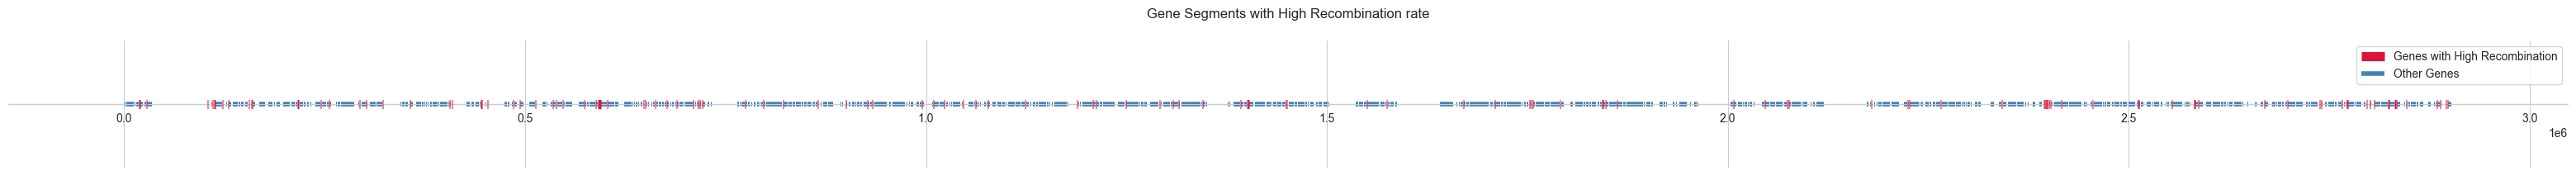

In [55]:
y_level = 0
gene_starts = np.delete(gene_info_np[:, 1], no_signal_id)
gene_ends   = np.delete(gene_info_np[:, 2], no_signal_id)

# high_recomb_index = np.where(ci_lower_bounds_rescaled >= 0.0003887292720131564)[0]
high_recomb_index = np.where(ci_lower_bounds_rescaled >= median_rho)[0]
highlight_starts = gene_starts[high_recomb_index]
highlight_ends   = gene_ends[high_recomb_index]

# other_genes_index = np.where(ci_lower_bounds_rescaled < 0.0003887292720131564)[0]
other_genes_index = np.where(ci_lower_bounds_rescaled < median_rho)[0]
other_starts = gene_starts[other_genes_index]
other_ends   = gene_ends[other_genes_index]

fig, ax = plt.subplots(figsize=(40, 2))

ax.axhline(y=y_level, color='lightgray', linewidth=1, zorder=1)
ax.hlines(y=[y_level] * len(highlight_starts), xmin=highlight_starts, xmax=highlight_ends, 
          color='crimson', linewidth=8, label='Genes with High Recombination', zorder=3)
ax.hlines(y=[y_level] * len(other_starts), xmin=other_starts, xmax=other_ends, 
          color='steelblue', linewidth=4, label='Other Genes', zorder=2)

ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_position('center')

ax.set_ylim(-1, 1)
ax.set_title("Gene Segments with High Recombination rate", pad=20)
ax.legend(loc='upper right')
plt.show()